# Week 12 Workshop: Creating Custom Visualizations with Seaborn

## Retail Executive Dashboard and Advanced Customer Analysis

In this notebook, I used the three retail CSV files to look at sales and customer patterns. I created:

1. A **2 × 2 executive dashboard**
2. An **income vs. spending chart** for the bonus section
3. A short summary of what I noticed

The notebook looks for the three CSV files in the same folder, a `data` folder, or an `upload` folder.


## 1. Setup, validation, and data preparation

First, I loaded the three files and checked that the columns needed for the assignment were there. I also converted the date and number columns so they would work correctly in the charts.


In [1]:
"""Week 12 Workshop: Creating Custom Visualizations with Seaborn.

Place the three CSV files beside this file or in a data/upload folder, then run
the script. It creates the dashboard and bonus chart in an outputs folder.
"""

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import pandas as pd
import seaborn as sns


DAY_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

AGE_ORDER = ["Under 30", "30-45", "46-60", "Over 60"]

REQUIRED_COLUMNS = {
    "customers.csv": {"customer_id", "age", "income", "state", "registration_date"},
    "products.csv": {"product_id", "category", "launch_date"},
    "sales.csv": {"customer_id", "product_id", "transaction_date", "total_amount"},
}


def currency_axis(value, _position=None):
    """Format a number as compact U.S. currency for chart axes."""
    return f"${value:,.0f}"


def find_csv(filename, data_dir=None):
    """Find one of the workshop CSV files."""
    base = Path(data_dir) if data_dir else Path.cwd()
    filename_options = {
        "customers.csv": ["customers.csv", "customers-1.csv", "customers-1(1).csv"],
        "products.csv": ["products.csv", "products(1).csv"],
        "sales.csv": ["sales.csv", "sales(1).csv"],
    }
    candidates = [
        folder / candidate_name
        for folder in (base, base / "data", base / "upload")
        for candidate_name in filename_options[filename]
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = "\n  - ".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in one of these locations:\n  - {searched}"
    )


def validate_columns(frame, filename):
    """Stop early with a clear message if a source file has missing columns."""
    missing = REQUIRED_COLUMNS[filename] - set(frame.columns)
    if missing:
        raise ValueError(
            f"{filename} is missing required column(s): {', '.join(sorted(missing))}"
        )


def load_and_prepare_data(data_dir=None):
    """Load, validate, clean, merge, and summarize the three workshop files."""
    customers = pd.read_csv(find_csv("customers.csv", data_dir))
    products = pd.read_csv(find_csv("products.csv", data_dir))
    sales = pd.read_csv(find_csv("sales.csv", data_dir))

    for filename, frame in {
        "customers.csv": customers,
        "products.csv": products,
        "sales.csv": sales,
    }.items():
        validate_columns(frame, filename)

    customers["registration_date"] = pd.to_datetime(
        customers["registration_date"], errors="coerce"
    )
    products["launch_date"] = pd.to_datetime(products["launch_date"], errors="coerce")
    sales["transaction_date"] = pd.to_datetime(
        sales["transaction_date"], errors="coerce"
    )

    customers["age"] = pd.to_numeric(customers["age"], errors="coerce")
    customers["income"] = pd.to_numeric(customers["income"], errors="coerce")
    sales["total_amount"] = pd.to_numeric(sales["total_amount"], errors="coerce")

    customers = customers.dropna(subset=["customer_id", "age", "income", "state"]).copy()
    products = products.dropna(subset=["product_id", "category"]).copy()
    sales = sales.dropna(
        subset=["customer_id", "product_id", "transaction_date", "total_amount"]
    ).copy()

    if customers.empty or products.empty or sales.empty:
        raise ValueError("A required dataset has no usable rows after validation.")

    sales["day_name"] = sales["transaction_date"].dt.day_name()

    sales_with_category = sales.merge(
        products[["product_id", "category"]],
        on="product_id",
        how="inner",
        validate="many_to_one",
    )
    category_revenue = (
        sales_with_category.groupby("category", observed=True)["total_amount"]
        .sum()
        .sort_values(ascending=False)
    )
    state_customer_counts = customers["state"].value_counts()
    daily_avg_amount = (
        sales.groupby("day_name")["total_amount"]
        .mean()
        .reindex(DAY_ORDER)
    )

    return {
        "customers": customers,
        "products": products,
        "sales": sales,
        "category_revenue": category_revenue,
        "state_customer_counts": state_customer_counts,
        "daily_avg_amount": daily_avg_amount,
    }


def set_professional_style():
    """Apply one consistent executive-friendly style to all charts."""
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "font.family": "DejaVu Sans",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.titleweight": "bold",
        }
    )


In [2]:

set_professional_style()
prepared = load_and_prepare_data()

customers = prepared["customers"]
products = prepared["products"]
sales = prepared["sales"]

print("Data loaded successfully")
print(f"  Customers: {len(customers):,}")
print(f"  Products: {len(products):,}")
print(f"  Sales transactions: {len(sales):,}")
print(f"  Total revenue: ${sales['total_amount'].sum():,.2f}")
print(f"  Average transaction: ${sales['total_amount'].mean():,.2f}")


Data loaded successfully
  Customers: 100
  Products: 60
  Sales transactions: 150
  Total revenue: $13,409.03
  Average transaction: $89.39


## 2. Executive dashboard

I used four charts so the main results could be seen in one place:

- Which product categories generate the most revenue?
- Where are the largest customer concentrations?
- How does average transaction value vary throughout the week?
- What is the shape and mean of the transaction-value distribution?


In [3]:
def create_executive_dashboard(prepared, output_path=None):
    """Create the required professional 2x2 executive dashboard."""
    customers = prepared["customers"]
    products = prepared["products"]
    sales = prepared["sales"]
    category_revenue = prepared["category_revenue"]
    state_customer_counts = prepared["state_customer_counts"]
    daily_avg_amount = prepared["daily_avg_amount"]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    ax1, ax2, ax3, ax4 = axes.flatten()
    fig.suptitle(
        "Retail Performance Executive Dashboard",
        fontsize=22,
        fontweight="bold",
        y=0.995,
    )

    category_plot = category_revenue.rename_axis("category").reset_index(name="revenue")
    sns.barplot(
        data=category_plot,
        x="revenue",
        y="category",
        hue="category",
        palette="Blues_r",
        legend=False,
        ax=ax1,
    )
    ax1.set_title("Revenue by Product Category")
    ax1.set_xlabel("Total Revenue")
    ax1.set_ylabel("Product Category")
    ax1.xaxis.set_major_formatter(FuncFormatter(currency_axis))
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax1.grid(axis="y", visible=False)

    top_states = state_customer_counts.head(6)
    state_plot = top_states.rename_axis("state").reset_index(name="customers")
    sns.barplot(
        data=state_plot,
        x="customers",
        y="state",
        hue="state",
        palette="crest",
        legend=False,
        ax=ax2,
    )
    state_count = len(top_states)
    state_title = (
        "Customer Distribution: Top 6 States"
        if state_count == 6
        else f"Customer Distribution by State ({state_count} Available)"
    )
    ax2.set_title(state_title)
    ax2.set_xlabel("Number of Customers")
    ax2.set_ylabel("State")
    ax2.grid(axis="y", visible=False)

    sns.lineplot(
        x=DAY_ORDER,
        y=daily_avg_amount.values,
        marker="o",
        markersize=9,
        linewidth=2.5,
        color="#136F8A",
        ax=ax3,
    )
    ax3.set_title("Average Transaction Amount by Day")
    ax3.set_xlabel("Day of Week")
    ax3.set_ylabel("Average Transaction Amount")
    ax3.yaxis.set_major_formatter(FuncFormatter(currency_axis))
    ax3.tick_params(axis="x", rotation=30)

    transaction_amounts = sales["total_amount"]
    mean_amount = transaction_amounts.mean()
    sns.histplot(
        transaction_amounts,
        bins=15,
        kde=True,
        color="#4C78A8",
        alpha=0.75,
        edgecolor="white",
        ax=ax4,
    )
    ax4.axvline(
        mean_amount,
        color="#C53B32",
        linestyle="--",
        linewidth=2.5,
        label=f"Mean: ${mean_amount:,.2f}",
    )
    ax4.set_title("Transaction Amount Distribution")
    ax4.set_xlabel("Transaction Amount")
    ax4.set_ylabel("Number of Transactions")
    ax4.xaxis.set_major_formatter(FuncFormatter(currency_axis))
    ax4.legend(frameon=True)

    overview = (
        f"Revenue: \\${sales['total_amount'].sum():,.0f}  |  "
        f"Avg. transaction: \\${sales['total_amount'].mean():,.2f}  |  "
        f"Categories: {products['category'].nunique()}  |  "
        f"Customers: {len(customers):,}"
    )
    fig.text(0.5, 0.955, overview, ha="center", fontsize=11, color="#374151")
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")
    return fig


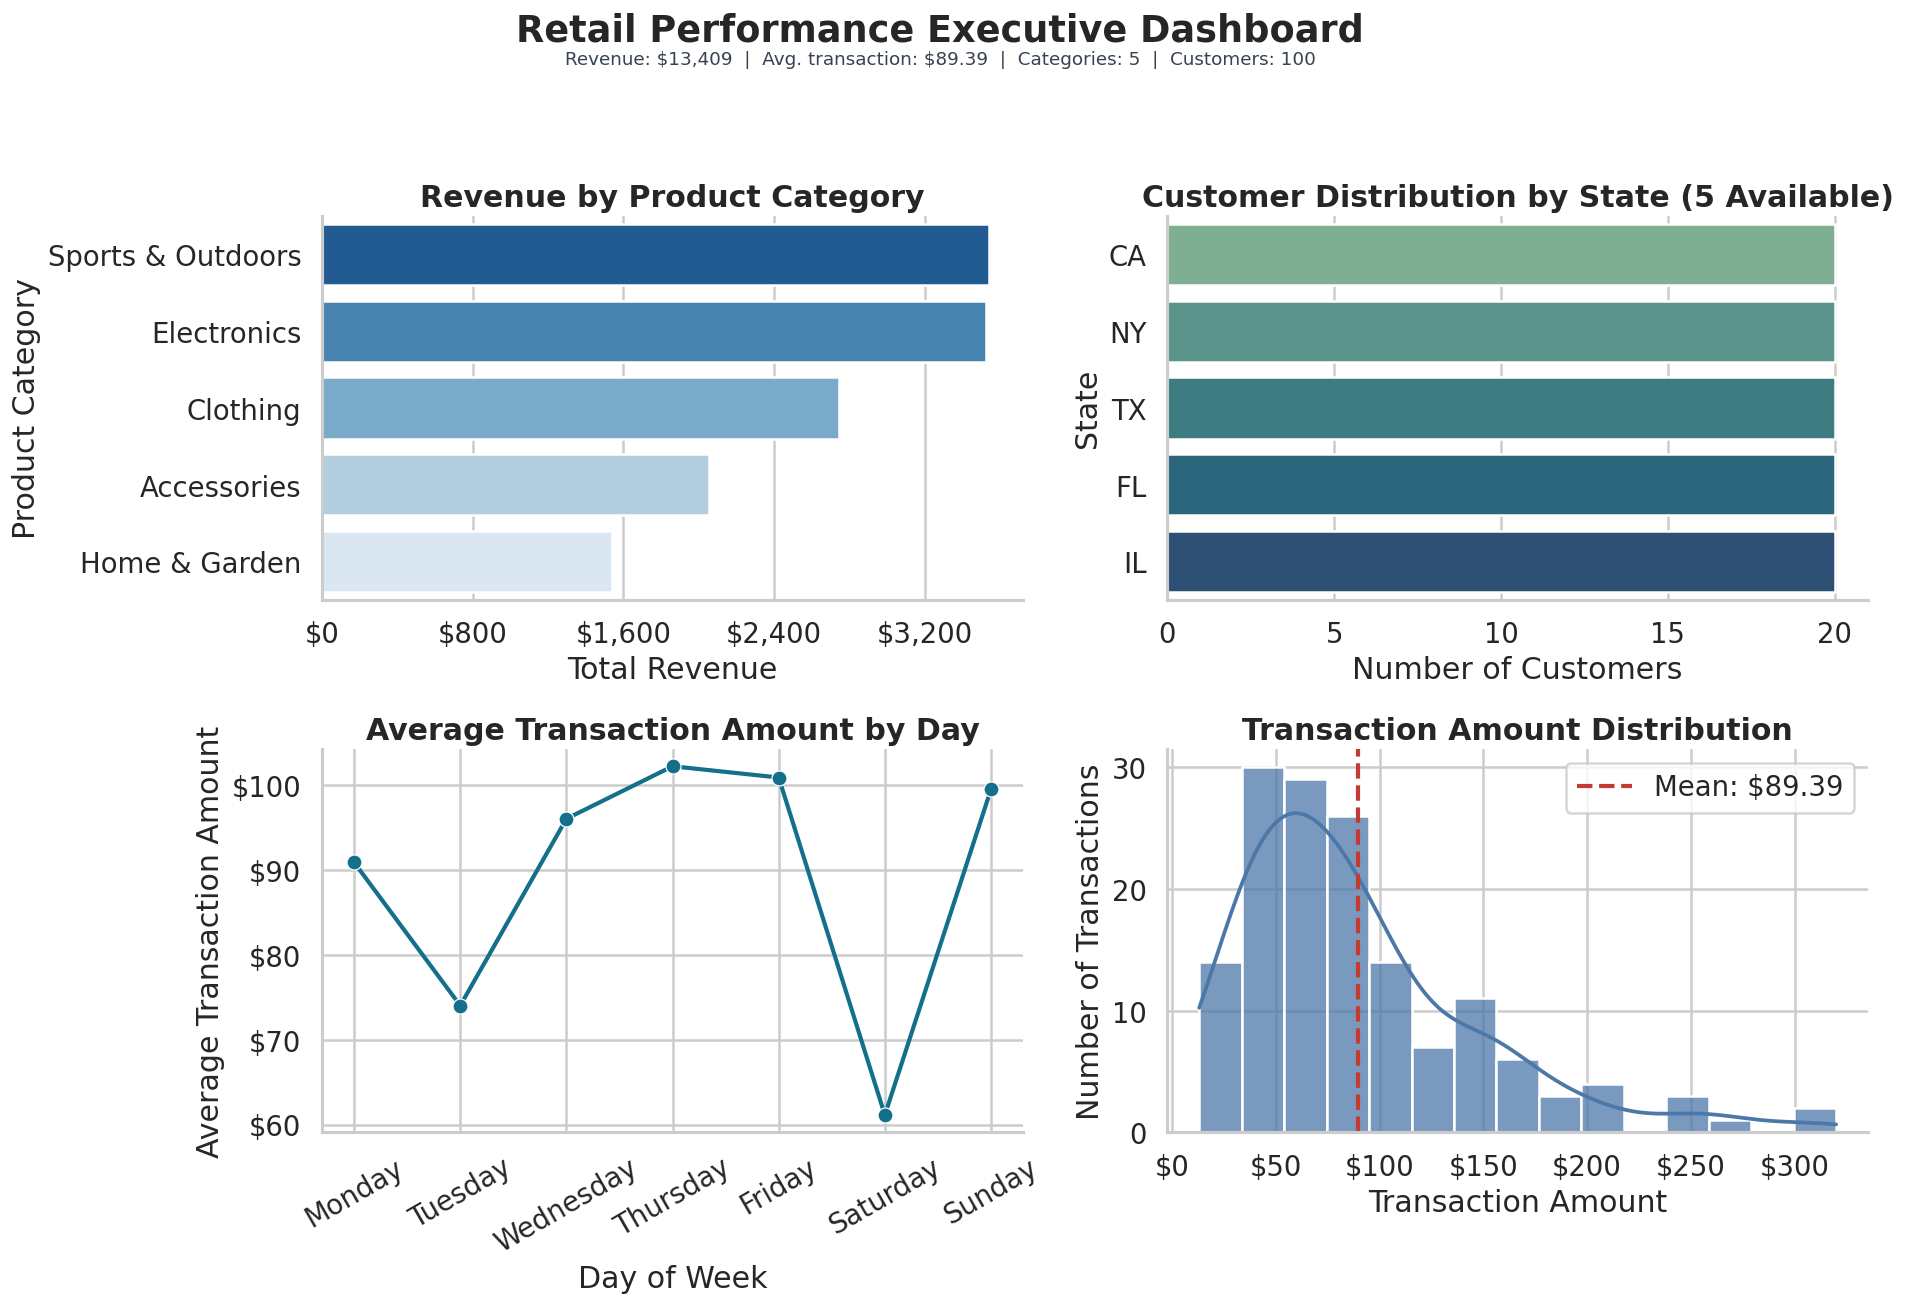

In [4]:

dashboard_path = Path("outputs/executive_dashboard.png")
dashboard_figure = create_executive_dashboard(prepared, dashboard_path)
plt.show()


## 3. Bonus: customer-level data preparation

I grouped the sales by customer to find each customer's total spending and purchase count. I used a **left merge** so customers with no purchases would still be included. Their spending and purchase count were changed to zero. Then I made the four age groups from the directions.


In [5]:
def prepare_customer_analysis(customers, sales):
    """Create one row per customer, including customers with no purchases."""
    customer_spending = (
        sales.groupby("customer_id")["total_amount"]
        .agg(total_spent="sum", purchase_count="count")
        .reset_index()
    )
    customer_analysis = customers.merge(
        customer_spending,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
    customer_analysis[["total_spent", "purchase_count"]] = customer_analysis[
        ["total_spent", "purchase_count"]
    ].fillna(0)

    # Using 29 as the first upper boundary ensures that age 30 belongs to 30-45.
    customer_analysis["age_group"] = pd.cut(
        customer_analysis["age"],
        bins=[float("-inf"), 29, 45, 60, float("inf")],
        labels=AGE_ORDER,
        ordered=True,
    )
    return customer_analysis


In [6]:

customer_analysis = prepare_customer_analysis(customers, sales)

print(f"Customer analysis rows: {len(customer_analysis):,}")
print(f"Customers with no purchases: {(customer_analysis['purchase_count'] == 0).sum():,}")
display(
    customer_analysis[
        ["customer_id", "age", "age_group", "income", "total_spent", "purchase_count"]
    ].head()
)


Customer analysis rows: 100
Customers with no purchases: 10


,customer_id,age,age_group,income,total_spent,purchase_count
0,1,34,30-45,75000,229.98,2.0
1,2,28,Under 30,82000,179.96,2.0
2,3,45,30-45,95000,154.98,2.0
3,4,31,30-45,68000,234.95,2.0
4,5,52,46-60,110000,149.98,2.0


## 4. Bonus: layered business intelligence visualization

This chart includes all five layers from the bonus directions:

1. Customer scatter points colored by age group
2. Overall regression line with a 95% confidence interval
3. Average-spending and 75th-percentile income reference lines
4. Correlation, customer counts, and conversion metrics
5. A callout for the age group with the highest average spending per customer

I used the average customer spending as the target because the files did not include a separate company target. I used the 75th percentile as the high-income line.


In [7]:
def create_advanced_visualization(customer_analysis, output_path=None):
    """Create the five-layer bonus visualization and return its metrics."""
    fig, ax = plt.subplots(figsize=(15, 9))
    age_palette = {
        "Under 30": "#2A9D8F",
        "30-45": "#457B9D",
        "46-60": "#E9C46A",
        "Over 60": "#E76F51",
    }

    present_age_groups = [
        group
        for group in AGE_ORDER
        if (customer_analysis["age_group"] == group).any()
    ]

    sns.scatterplot(
        data=customer_analysis,
        x="income",
        y="total_spent",
        hue="age_group",
        hue_order=present_age_groups,
        palette=age_palette,
        alpha=0.72,
        s=85,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )

    if (
        customer_analysis["income"].nunique() > 1
        and customer_analysis["total_spent"].nunique() > 1
    ):
        sns.regplot(
            data=customer_analysis,
            x="income",
            y="total_spent",
            scatter=False,
            ci=95,
            color="#8B1E3F",
            line_kws={"linewidth": 3, "label": "Overall trend (95% CI)"},
            ax=ax,
        )
        ax.lines[-1].set_label("Overall trend (95% CI)")

    # The overall average is used as the spending target because no company
    # target was included in the workshop files.
    target_spending = customer_analysis["total_spent"].mean()
    high_income_threshold = customer_analysis["income"].quantile(0.75)
    ax.axhline(
        target_spending,
        color="#2E7D32",
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Target (overall average): ${target_spending:,.0f}",
    )
    ax.axvline(
        high_income_threshold,
        color="#F28E2B",
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"High-income threshold: ${high_income_threshold:,.0f}",
    )

    correlation = customer_analysis["income"].corr(customer_analysis["total_spent"])
    high_income_mask = customer_analysis["income"] >= high_income_threshold
    high_spender_mask = customer_analysis["total_spent"] >= target_spending
    high_income_customers = int(high_income_mask.sum())
    high_spenders = int(high_spender_mask.sum())
    purchasers = int((customer_analysis["purchase_count"] > 0).sum())
    purchase_conversion = purchasers / len(customer_analysis) * 100
    high_income_conversion = (
        (high_income_mask & high_spender_mask).sum() / high_income_customers * 100
        if high_income_customers
        else 0
    )

    correlation_text = "N/A" if pd.isna(correlation) else f"{correlation:.3f}"
    ax.text(
        0.02,
        0.97,
        f"Income-spending correlation: {correlation_text}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#DCEFF7", alpha=0.92),
    )

    insight_text = (
        f"Customers: {len(customer_analysis):,}\n"
        f"Customers with purchases: {purchasers:,}\n"
        f"Purchase conversion: {purchase_conversion:.1f}%\n"
        f"High-income customers: {high_income_customers:,}\n"
        f"High-income above target: {high_income_conversion:.1f}%"
    )
    ax.text(
        0.98,
        0.97,
        insight_text,
        transform=ax.transAxes,
        fontsize=10.5,
        va="top",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.55", facecolor="#FFF4D6", alpha=0.94),
    )

    age_group_avg = customer_analysis.groupby(
        "age_group", observed=True
    )["total_spent"].mean()
    top_age_group = age_group_avg.idxmax()
    top_avg_spending = age_group_avg.max()
    top_customer = customer_analysis[
        customer_analysis["age_group"] == top_age_group
    ].nlargest(1, "total_spent")

    if not top_customer.empty:
        ax.annotate(
            f"Top-performing age group\n{top_age_group}: ${top_avg_spending:,.0f} avg.",
            xy=(top_customer["income"].iloc[0], top_customer["total_spent"].iloc[0]),
            xytext=(0.57, 0.76),
            textcoords="axes fraction",
            fontsize=10.5,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="#FFF59D", alpha=0.94),
            arrowprops=dict(
                arrowstyle="->", connectionstyle="arc3,rad=0.15", color="#374151"
            ),
        )

    ax.set_title(
        "Customer Income and Spending Analysis",
        fontsize=18,
        fontweight="bold",
        pad=18,
    )
    ax.set_xlabel("Annual Income")
    ax.set_ylabel("Total Amount Spent")
    ax.xaxis.set_major_formatter(FuncFormatter(currency_axis))
    ax.yaxis.set_major_formatter(FuncFormatter(currency_axis))
    ax.legend(
        title="Age Groups and Reference Lines",
        bbox_to_anchor=(1.02, 0.72),
        loc="upper left",
        frameon=True,
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()

    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")

    metrics = {
        "correlation": correlation,
        "customer_count": len(customer_analysis),
        "purchase_conversion_pct": purchase_conversion,
        "high_income_customers": high_income_customers,
        "high_spenders": high_spenders,
        "high_income_above_target_pct": high_income_conversion,
        "top_age_group": str(top_age_group),
        "top_age_group_avg_spending": top_avg_spending,
    }
    return fig, metrics


,Value
correlation,-0.099784
customer_count,100
purchase_conversion_pct,90.0
high_income_customers,25
high_spenders,51
high_income_above_target_pct,40.0
top_age_group,Under 30
top_age_group_avg_spending,142.7225


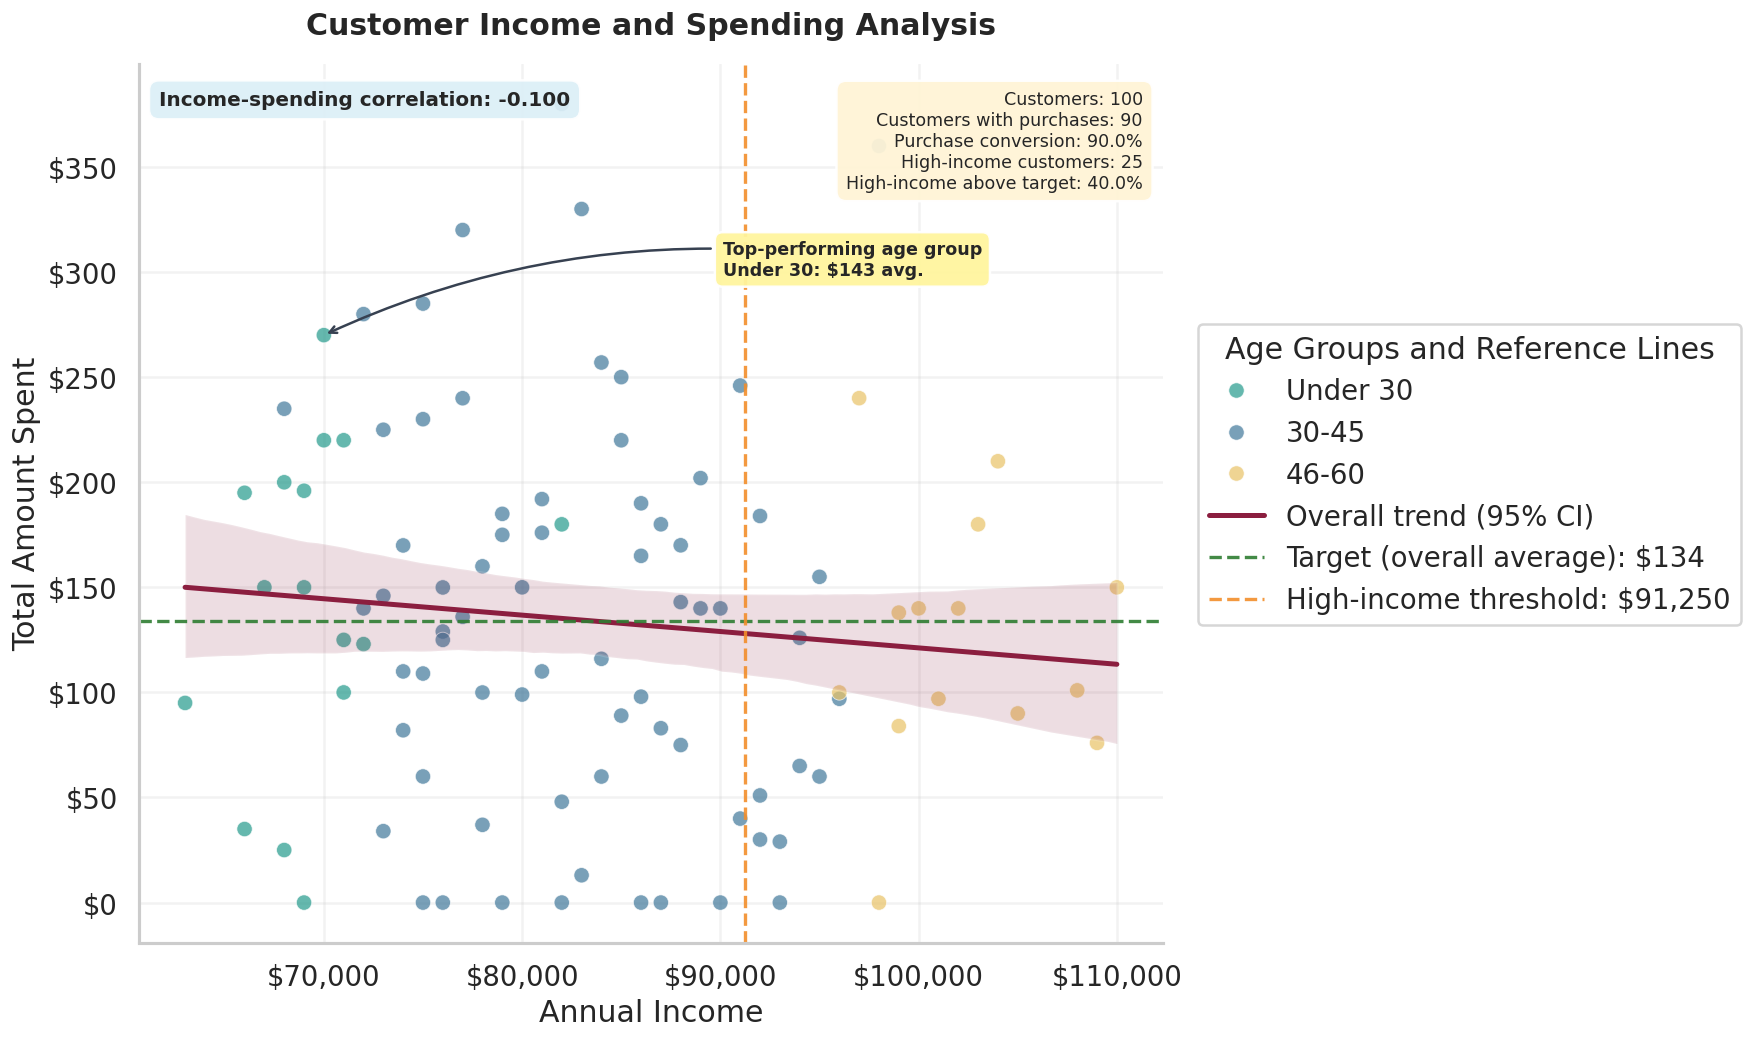

In [8]:

advanced_path = Path("outputs/advanced_customer_analysis.png")
advanced_figure, metrics = create_advanced_visualization(
    customer_analysis, advanced_path
)
plt.show()

metrics_display = pd.Series(metrics, name="Value").to_frame()
display(metrics_display)


## 5. What I learned from the charts

The summary below uses the results from the real workshop data. The top age group is based on average spending for everyone in that group, including customers who did not make a purchase.


In [9]:

best_category = prepared["category_revenue"].idxmax()
best_category_revenue = prepared["category_revenue"].max()
highest_day = prepared["daily_avg_amount"].idxmax()
highest_day_average = prepared["daily_avg_amount"].max()
lowest_day = prepared["daily_avg_amount"].idxmin()
lowest_day_average = prepared["daily_avg_amount"].min()

print("What I noticed from the charts:")
print(f"1. {best_category} had the highest revenue at ${best_category_revenue:,.2f}.")
print(f"2. {highest_day} had the highest average transaction at ${highest_day_average:,.2f}.")
print(f"3. {lowest_day} had the lowest average transaction at ${lowest_day_average:,.2f}.")
print(f"4. The income and spending correlation was {metrics['correlation']:.3f}, so the relationship was very weak.")
print(f"5. The {metrics['top_age_group']} group had the highest average spending per customer.")
print()
print("My recommendation:")
print(
    "The company could keep promoting its strongest product categories and look "
    "for ways to improve the lower-spending days. Income by itself should not be "
    "used to target customers because it did not have a strong relationship with spending."
)


What I noticed from the charts:
1. Sports & Outdoors had the highest revenue at $3,544.64.
2. Thursday had the highest average transaction at $102.27.
3. Saturday had the lowest average transaction at $61.12.
4. The income and spending correlation was -0.100, so the relationship was very weak.
5. The Under 30 group had the highest average spending per customer.

My recommendation:
The company could keep promoting its strongest product categories and look for ways to improve the lower-spending days. Income by itself should not be used to target customers because it did not have a strong relationship with spending.
